## Simple Poisson Solver

## Visualizating the results

Below we give some python code to visualizate the solution using yt:

In [1]:
import yt
from yt.frontends import boxlib
from yt.frontends.boxlib.data_structures import AMReXDataset
import numpy as np
import matplotlib.pyplot as plt
import os

N = 128
N2 = int(N / 2)

/tmp/ipykernel_1425282/2637993011.py:3: DeprecationWarning: The historic 'boxlib' frontend is 
deprecated as it has been renamed 'amrex'. Existing and future work should instead reference the 'amrex' frontend.
Deprecated since yt 4.4.0
  from yt.frontends.boxlib.data_structures import AMReXDataset


In [2]:
ls

 AxNyx3d.gnu.MPI.ex*           inputs_final            Output/
 Backtrace.0                   inputs_for_preprocess   preprocess_input.py
 clean.sh*                     inputs_template         Prob.cpp
'ComovSingleField analysis'/   jobscript.job           runcode.sh*
 GNUmakefile                   Make.package            tmp_build_dir/
 inputs                        mem_info.log            Visualization.ipynb


### Energy Density

In [20]:
ds = AMReXDataset("Output/plt00000")

yt : [INFO     ] 2026-04-29 17:04:34,544 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-04-29 17:04:34,545 Parameters: domain_dimensions         = [8 8 8]
yt : [INFO     ] 2026-04-29 17:04:34,545 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-04-29 17:04:34,545 Parameters: domain_right_edge         = [1. 1. 1.]


In [21]:
ds.field_list

[('boxlib', 'Dens'),
 ('boxlib', 'Phase'),
 ('boxlib', 'SCHf_Im'),
 ('boxlib', 'SCHf_Re'),
 ('boxlib', 'phi_grav')]

In [19]:
sl = yt.SlicePlot(ds, 0, ('boxlib', 'grav_x'))

YTFieldNotFound: Could not find field ('boxlib', 'grav_x') in plt00000.


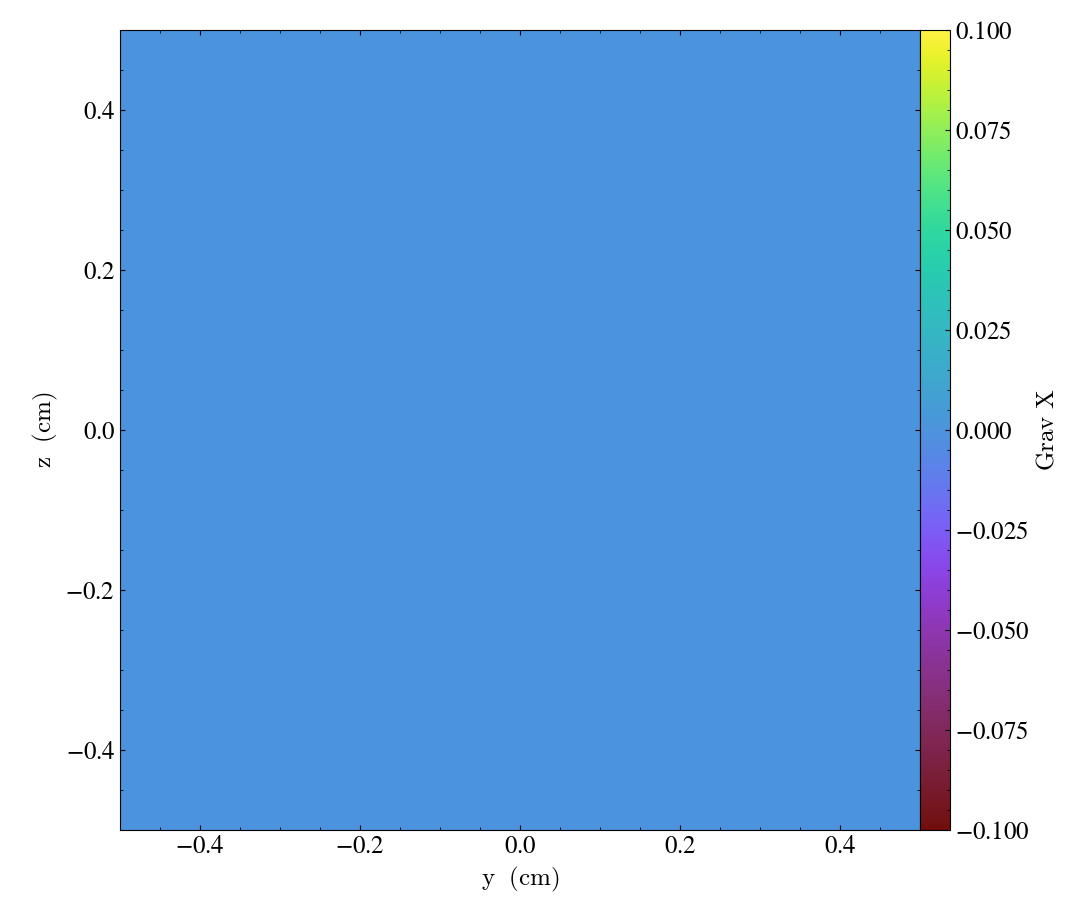

In [16]:
sl


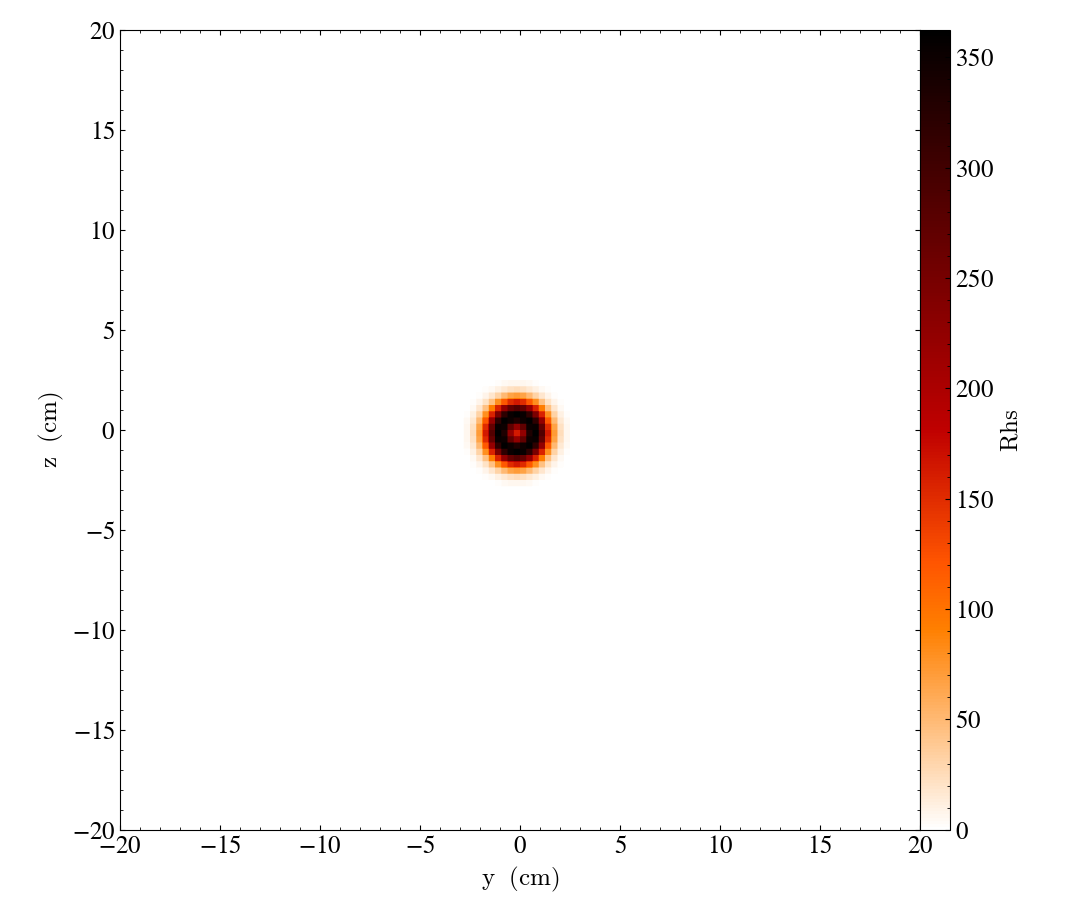

In [178]:
sl.set_log("rhs",False)
sl.set_cmap(("rhs"), "gist_heat_r")
sl

In [153]:
sl.save()

yt : [INFO     ] 2026-04-01 17:09:06,654 Saving plot plot_Slice_x_rhs.png


['plot_Slice_x_rhs.png']

### Newtonian Potential

yt : [INFO     ] 2026-04-01 17:09:07,160 xlim = 0.000000 40.000000
yt : [INFO     ] 2026-04-01 17:09:07,161 ylim = 0.000000 40.000000
yt : [INFO     ] 2026-04-01 17:09:07,162 xlim = 0.000000 40.000000
yt : [INFO     ] 2026-04-01 17:09:07,163 ylim = 0.000000 40.000000
yt : [INFO     ] 2026-04-01 17:09:07,164 Making a fixed resolution buffer of (('boxlib', 'Phi')) 800 by 800



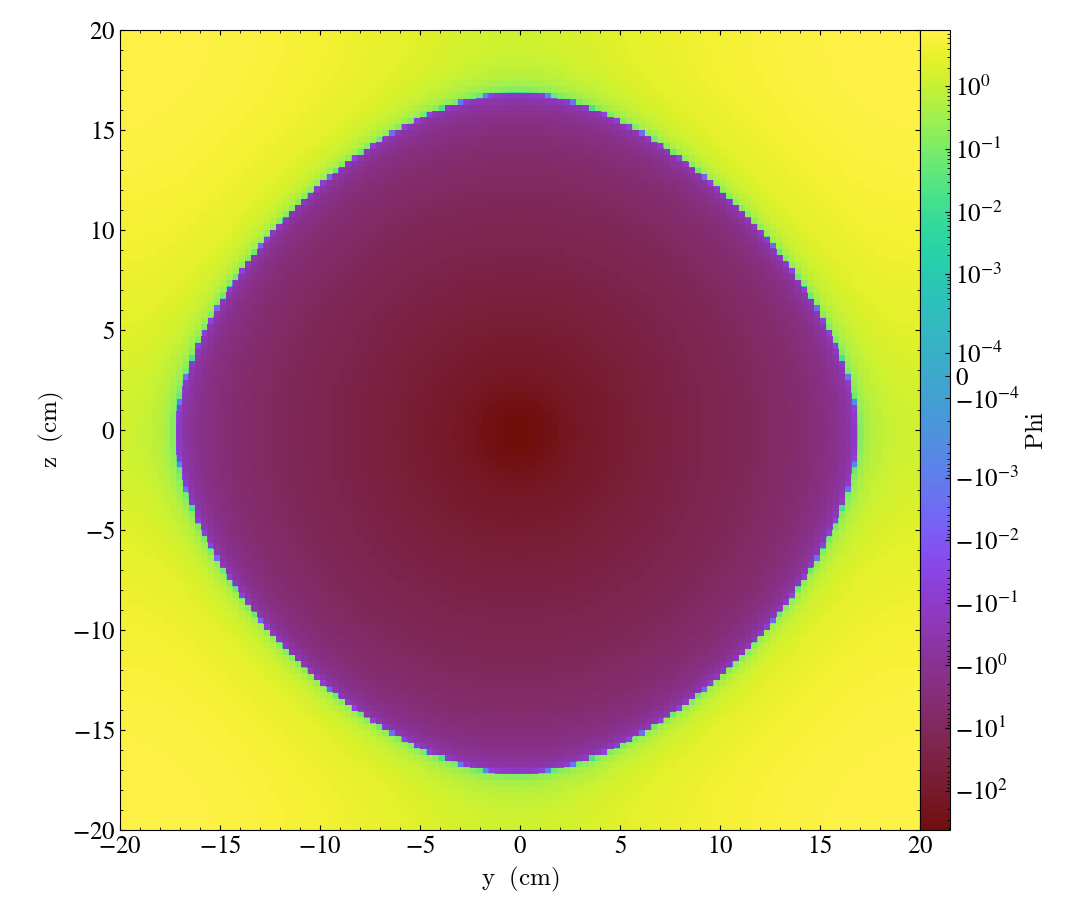

In [154]:
sl2 = yt.SlicePlot(ds, 0, ('boxlib', 'Phi'))
sl2


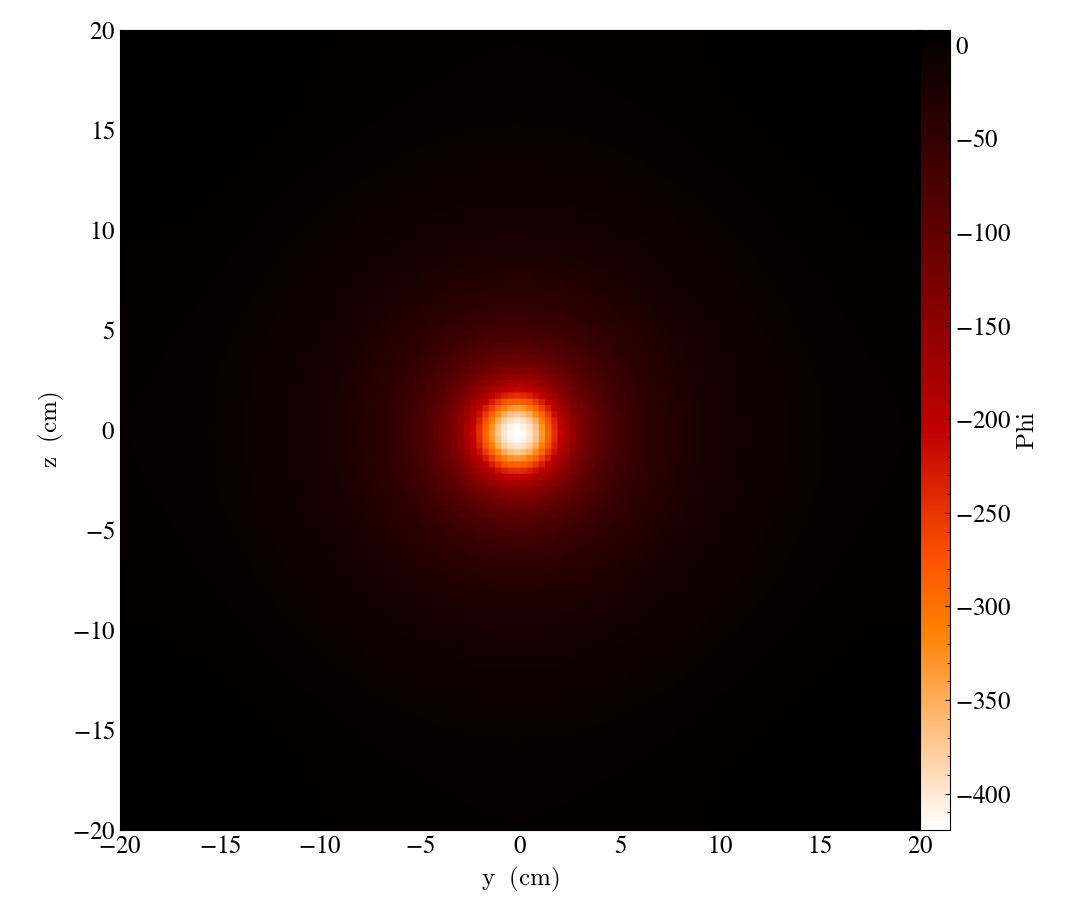

In [135]:
sl2.set_log("Phi",False)
sl2.set_cmap(("Phi"), "gist_heat_r")
sl2

In [122]:
sl2.save()

yt : [INFO     ] 2026-04-01 17:06:53,159 Saving plot plot_Slice_x_Phi.png


['plot_Slice_x_Phi.png']

yt : [INFO     ] 2026-04-01 17:06:53,515 xlim = 0.000000 40.000000
yt : [INFO     ] 2026-04-01 17:06:53,515 ylim = 0.000000 40.000000
yt : [INFO     ] 2026-04-01 17:06:53,517 xlim = 0.000000 40.000000
yt : [INFO     ] 2026-04-01 17:06:53,517 ylim = 0.000000 40.000000
yt : [INFO     ] 2026-04-01 17:06:53,518 Making a fixed resolution buffer of (('boxlib', 'exact_solution')) 800 by 800



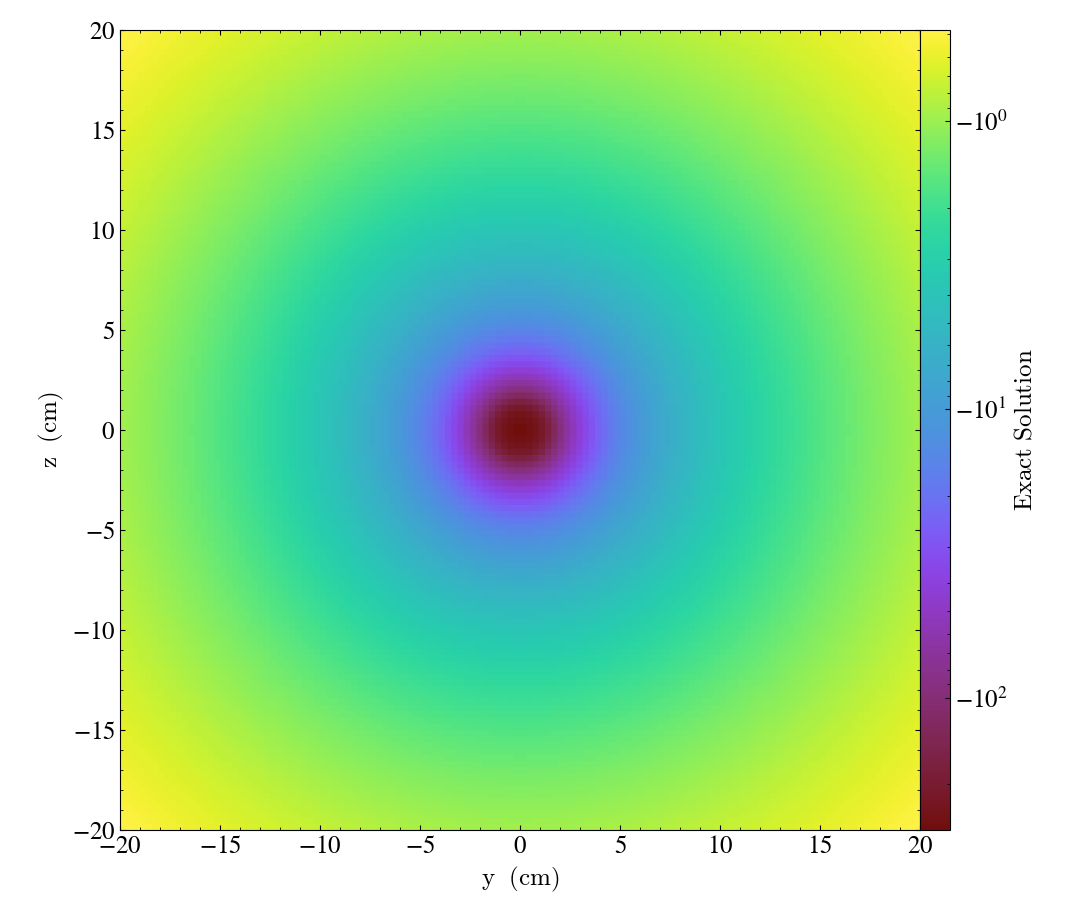

In [123]:
sl3 = yt.SlicePlot(ds, 0, ('boxlib', 'exact_solution'))
sl3


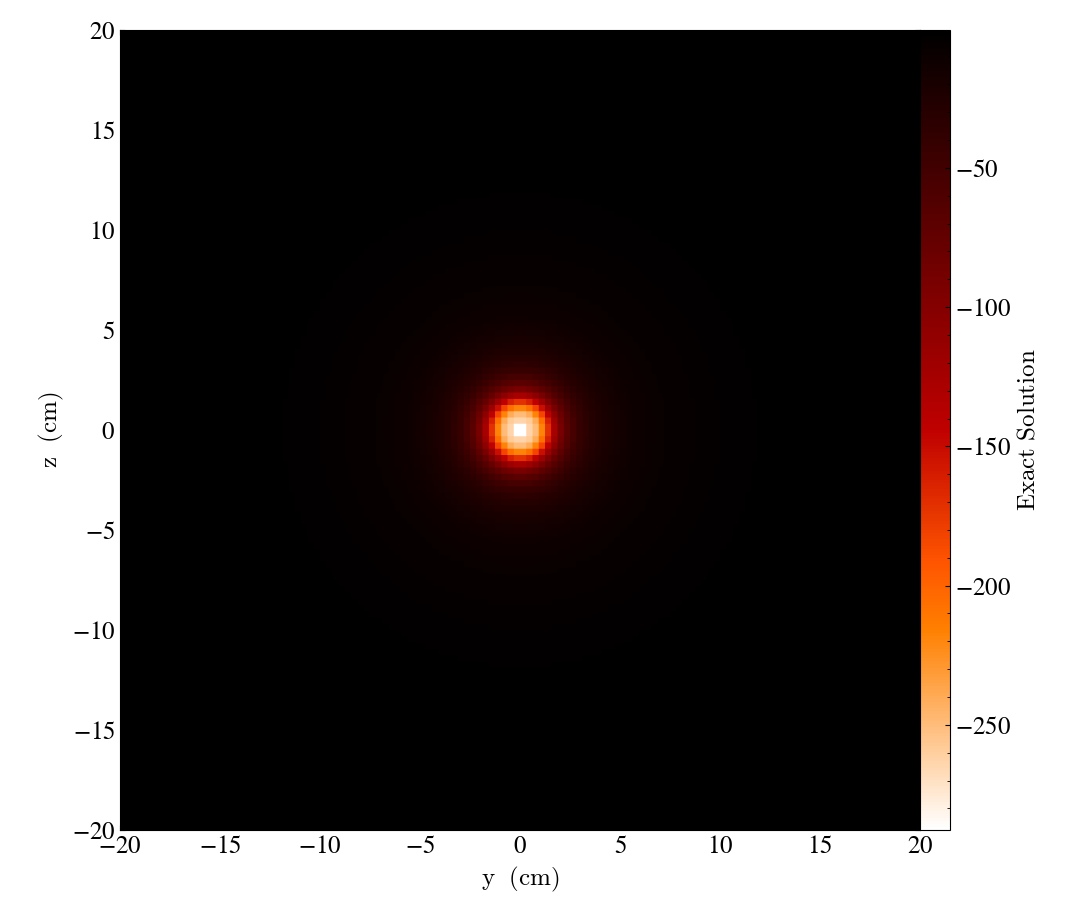

In [124]:
sl3.set_log("exact_solution",False)
sl3.set_cmap(("exact_solution"), "gist_heat_r")
sl3

In [37]:
#exact = np.genfromtxt("oscillon_phi.txt").reshape(512,512,512)
exact = np.genfromtxt("oscillon_profile.txt")

In [38]:
data = {"Phi": (exact, "")}
bbox = np.array([[-20,20],[-20,20],[-20,20]])
ds = yt.load_uniform_grid(data, exact.shape, length_unit="cm", bbox=bbox, nprocs=1)

NameError: name 'exact' is not defined

yt : [INFO     ] 2026-03-23 18:29:45,393 xlim = 0.000000 16.000000
yt : [INFO     ] 2026-03-23 18:29:45,394 ylim = 0.000000 16.000000
yt : [INFO     ] 2026-03-23 18:29:45,395 xlim = 0.000000 16.000000
yt : [INFO     ] 2026-03-23 18:29:45,395 ylim = 0.000000 16.000000
yt : [INFO     ] 2026-03-23 18:29:45,396 Making a fixed resolution buffer of (('boxlib', 'Phi')) 800 by 800



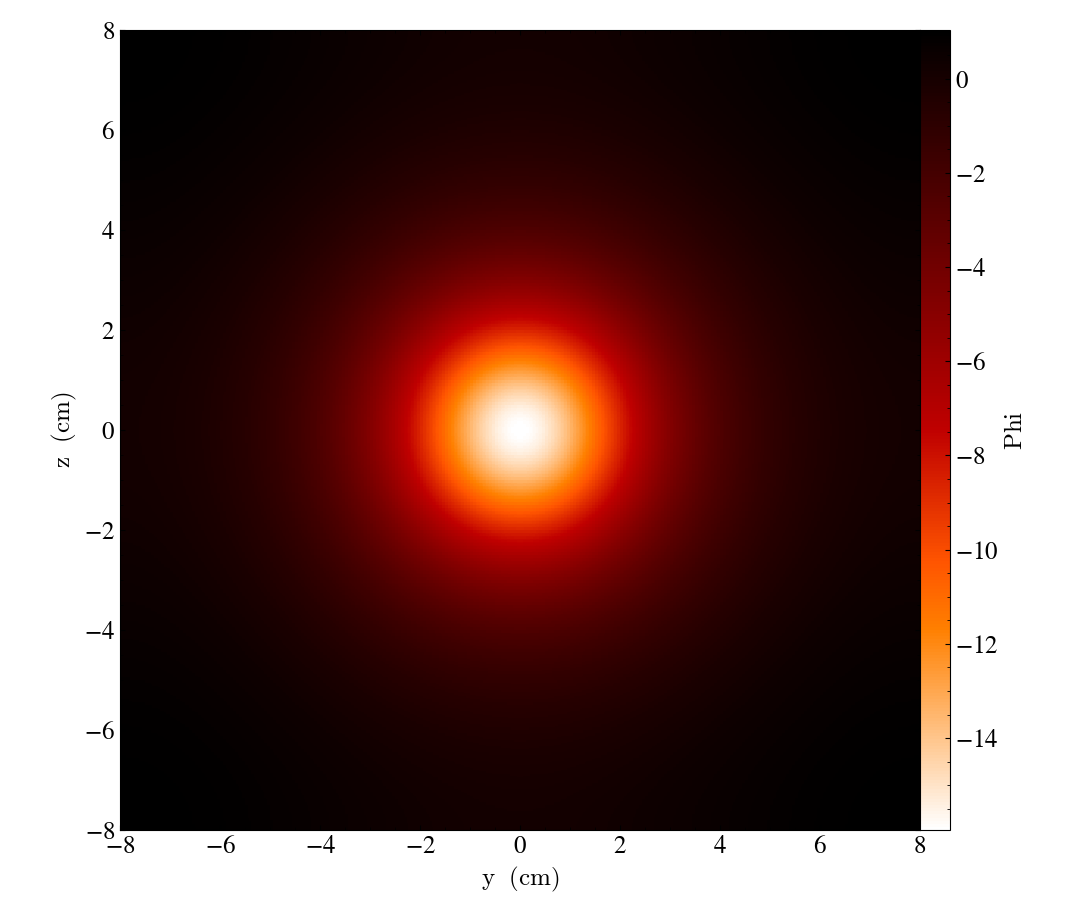

In [47]:
sl3 = yt.SlicePlot(ds2, "x", "Phi")
sl3.set_log("Phi",False)
sl3.set_cmap(("Phi"), "gist_heat_r")
sl3

In [ ]:
sl3.save()

yt : [INFO     ] 2026-03-17 14:55:51,398 Saving plot UniformGridData_Slice_x_Phi.png


['UniformGridData_Slice_x_Phi.png']

### Diff

In [179]:
#ds3 = AMReXDataset("Phi")
all_data_level_0 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[N,N,N])
print(all_data_level_0["boxlib","Phi"])

[[[10.89159473 10.88648774 10.87797327 ... 10.88648104 10.891593
   10.89326834]
  [10.88648774 10.88136868 10.87283824 ... 10.88136169 10.88648104
   10.88816273]
  [10.87797327 10.87283824 10.86428093 ... 10.87283143 10.87796278
   10.87965053]
  ...
  [10.88648104 10.88136169 10.87283143 ... 10.88136868 10.88648774
   10.88816273]
  [10.891593   10.88648104 10.87796278 ... 10.88648774 10.89159473
   10.89326834]
  [10.89326834 10.88816273 10.87965053 ... 10.88816273 10.89326834
   10.89494107]]

 [[10.88648774 10.88136868 10.87283824 ... 10.88136169 10.88648104
   10.88816273]
  [10.88136868 10.87624455 10.86770127 ... 10.8762318  10.88136169
   10.88304664]
  [10.87283824 10.86770127 10.85913487 ... 10.86768371 10.87283143
   10.87452037]
  ...
  [10.88136169 10.8762318  10.86768371 ... 10.87624455 10.88136868
   10.88304664]
  [10.88648104 10.88136169 10.87283143 ... 10.88136868 10.88648774
   10.88816273]
  [10.88816273 10.88304664 10.87452037 ... 10.88304664 10.88816273
   10.88

yt : [INFO     ] 2026-04-02 15:29:06,023 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-04-02 15:29:06,023 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2026-04-02 15:29:06,024 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-04-02 15:29:06,024 Parameters: domain_right_edge         = [40. 40. 40.]
/tmp/ipykernel_200160/4020181940.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Data/Phi/Phi10.txt


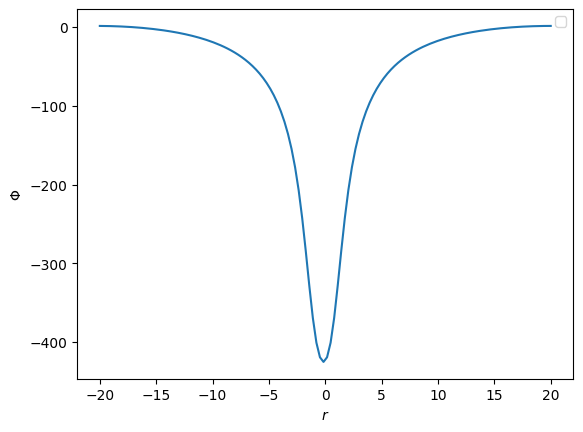

In [195]:
ds = AMReXDataset("plot")

all_data_level_0 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[N,N,N])

#diff = np.abs(np.min(all_data_level_0["boxlib","Phi"]) - np.min(exact))
plt.plot(np.linspace(-20, 20, N), all_data_level_0["boxlib","Phi"][N2,:,N2])
#plt.plot(np.linspace(-8, 8, N), exact,label="Theoretical")
plt.legend()
plt.ylabel(r"$\Phi$")
plt.xlabel(r"$r$")
save_dir = "Data/Phi/Phi10.txt"
if os.path.exists(save_dir):
    print("Rename file!")
else:
    np.savetxt(save_dir,all_data_level_0["boxlib","Phi"][N2,:,N2])
print(save_dir)

In [181]:
plt.semilogy(data_r,data_profile)
plt.xlabel(r"$r$ (pc)")
plt.ylabel(r"Density ($M_{\odot}$ / Mpc$^3$)")

NameError: name 'data_r' is not defined

In [15]:
soliton = np.loadtxt("soliton.txt")
print(np.shape(soliton))

(16777216,)


### $\dot{\Phi}$ Plot 

0.015
0.015
0.015
0.015
0.015
0.015
0.015
0.015000000000000013
0.014999999999999986
0.015000000000000013


Text(0, 0.5, '$\\dot{\\Phi} / \\Phi$')

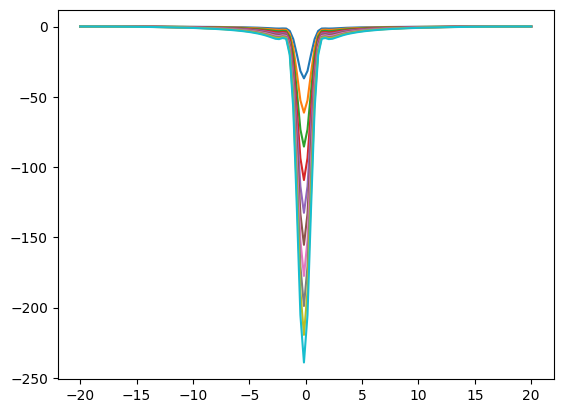

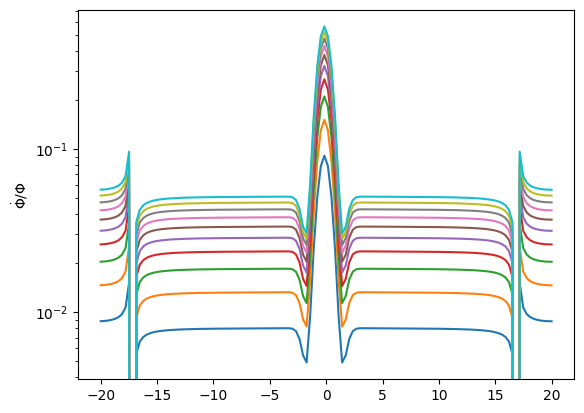

In [47]:
data0 = np.loadtxt("Data/Phi/Phi0.txt")
times = np.loadtxt("Data/slicetimes_0.dat")
for i in range(1,11):
    dt = times[i] - times[i-1]
    print(dt)
    data0 = np.loadtxt(f"Data/Phi/Phi{i-1}.txt")
    data = np.loadtxt(f"Data/Phi/Phi{i}.txt")
    phidot = (data - data0) / dt
    phidot_rel = 2 * phidot / (data + data0)
    plt.figure(1)
    plt.plot(np.linspace(-20,20,128),phidot)
    plt.figure(2)
    plt.semilogy(np.linspace(-20,20,128),phidot_rel)
    #data0 = data
#oscillon = np.loadtxt("Data/oscillon.txt")
#oscillon = oscillon.reshape([128,128,128])
#plt.plot(np.linspace(-20,20,128),oscillon[64,:,64], color='k', linestyle='--', label="Oscillon Profile")
#plt.legend()
plt.ylabel(r"$\dot{\Phi} / \Phi$")

-0.04855007035669493
-0.04861652850487405
-0.048726984858327
-0.048880978936577724
-0.04907786787491267
-0.04931682702108252
-0.04959686831133742
-0.04991681322564029
-0.0502753374345981
-0.05067094048544424
-0.051101966957990366


Text(0, 0.5, '$\\Phi$')

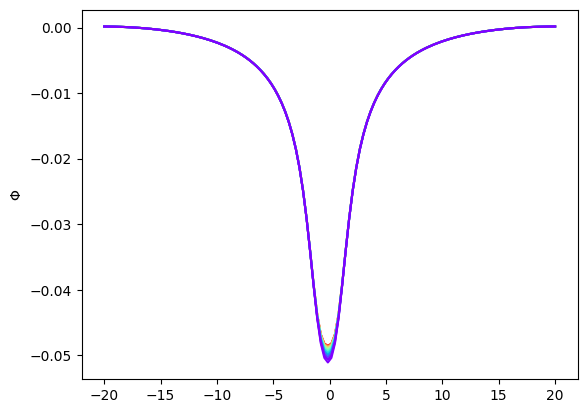

In [38]:
data0 = np.loadtxt("Data/Phi/Phi0.txt")
times = np.loadtxt("Data/slicetimes_0.dat")
n = 10
colours = plt.get_cmap('rainbow_r', n)
for i in range(0,n+1):
    dt = times[i] - times[i-1]
    data = np.loadtxt(f"Data/Phi/Phi{i}.txt")
    data /= (4.5 * 43 ** 2)
    plt.plot(np.linspace(-20,20,128),data,color = colours(i))
    print(np.min(data))
plt.ylabel(r"$\Phi$")

## Wild Oscillons

In [4]:
range_plot = [2,3,5,6,8,9,11,12,15,16,18,19,21,22,24,25,27,28]
range_plot2 = [3, 6, 9, 12, 16, 19, 22, 25, 28]

yt : [INFO     ] 2026-04-16 17:07:56,164 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-04-16 17:07:56,164 Parameters: domain_dimensions         = [256 256 256]
yt : [INFO     ] 2026-04-16 17:07:56,165 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-04-16 17:07:56,165 Parameters: domain_right_edge         = [40. 40. 40.]


Rename file!
Data/Phi/Phi28.txt


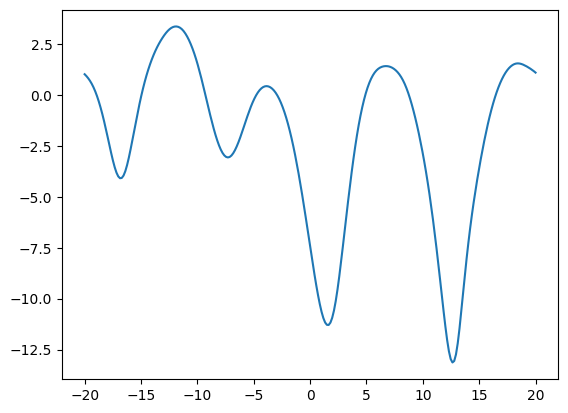

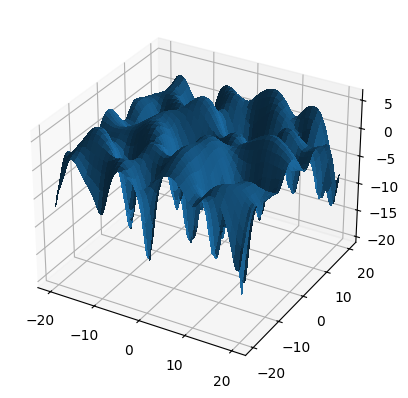

In [10]:
ds = AMReXDataset("plot")
N = 256
N2 = N // 2

all_data_level_0 = ds.covering_grid(level=0, left_edge=[0,0,0],dims=[N,N,N])
x0, y0 = np.meshgrid(np.linspace(-20, 20, N), np.linspace(-20, 20, N), indexing='ij')

plt.plot(np.linspace(-20, 20, N), all_data_level_0["boxlib","Phi"][N2,:,N2])
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x0, y0, all_data_level_0["boxlib","Phi"][:,:,N2], antialiased=False)
save_dir = "Data/Phi/Phi28.txt"
if os.path.exists(save_dir):
    print("Rename file!")
else:
    np.savetxt(save_dir,all_data_level_0["boxlib","Phi"][:,:,N2])
print(save_dir)

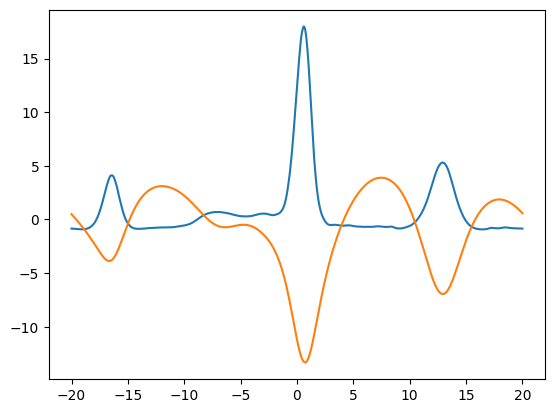

In [98]:
plt.plot(np.linspace(-20, 20, N), all_data_level_0["boxlib","rhs"][N2,:,N2])
plt.plot(np.linspace(-20, 20, N), all_data_level_0["boxlib","Phi"][N2,:,N2])

78072.76010972999
78073.5412669767
78072.7601097411
78072.76010972999
78072.7601097411
78072.7601097411
78072.76010972999
78072.7601097411
78073.5412669767


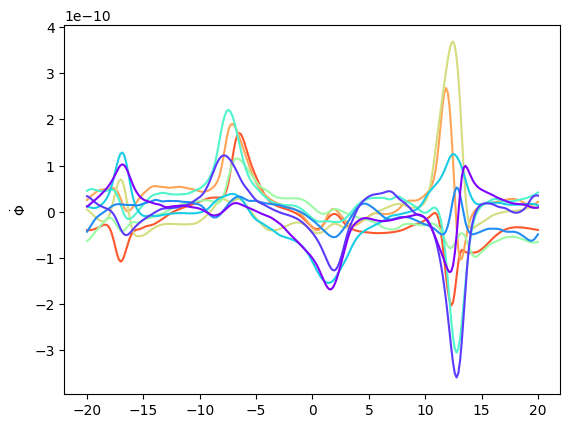

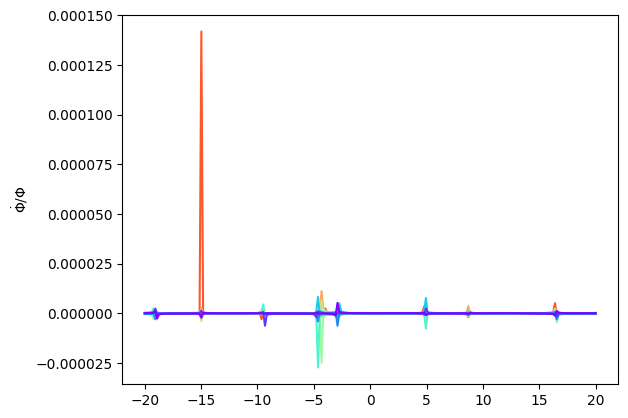

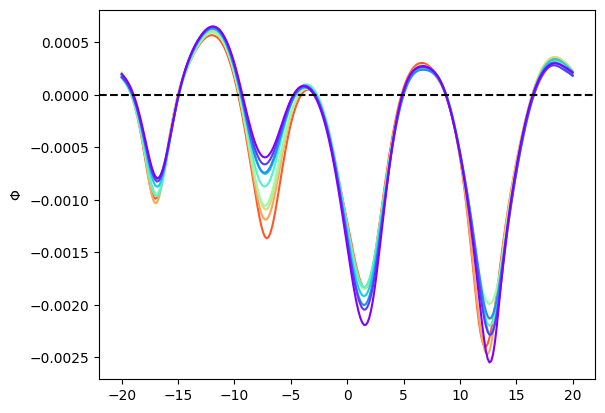

In [71]:
times = np.loadtxt("Data/slicetimes_0.dat")
sf = np.loadtxt("Data/sf_0.dat")
A = 4.300630e+01
B = 1.280152e-06
n = len(range(range_plot[-1]))
colours = plt.get_cmap('rainbow_r', n)

for i in range_plot2:
    dt = times[i] - times[i-1]
    dt /= B
    a = sf[i,1]
    constant = a * A ** 2
    print(dt)
    data0 = np.loadtxt(f"Data/Phi/Phi{i-1}.txt")
    data = np.loadtxt(f"Data/Phi/Phi{i}.txt")
    phi = data / constant
    phidot = (data - data0) / dt
    phidot_rel = 2 * phidot / (data + data0)
    plt.figure(1)
    plt.plot(np.linspace(-20,20,N),phidot[N2,:]/constant,color=colours(i))
    plt.figure(2)
    plt.plot(np.linspace(-20,20,N),phidot_rel[N2,:],color=colours(i))
    plt.figure(3)
    plt.plot(np.linspace(-20, 20, N), phi[N2,:],color=colours(i))
    #plt.ylim(-1,1)
    #data0 = data
#oscillon = np.loadtxt("Data/oscillon.txt")
#oscillon = oscillon.reshape([128,128,128])
#plt.plot(np.linspace(-20,20,128),oscillon[64,:,64], color='k', linestyle='--', label="Oscillon Profile")
#plt.legend()
plt.figure(1)
plt.ylabel(r"$\dot{\Phi}$")
plt.savefig("Phi_dot.png", dpi=200,facecolor='w',bbox_inches='tight')
plt.figure(2)
plt.ylabel(r"$\dot{\Phi} / \Phi$")
#plt.ylim(bottom=1e-10)
plt.savefig("Phi_dot_rel.png", dpi=200,facecolor='w',bbox_inches='tight')
plt.figure(3)
plt.ylabel(r"$\Phi$")
plt.axhline(0, color='k', linestyle='--')
plt.savefig("Phi.png", dpi=200,facecolor='w',bbox_inches='tight')

### $\dot{\Phi} / H$

78072.76010972999
78073.5412669767
78072.7601097411
78072.76010972999
78072.7601097411
78072.7601097411
78072.76010972999
78072.7601097411
78073.5412669767


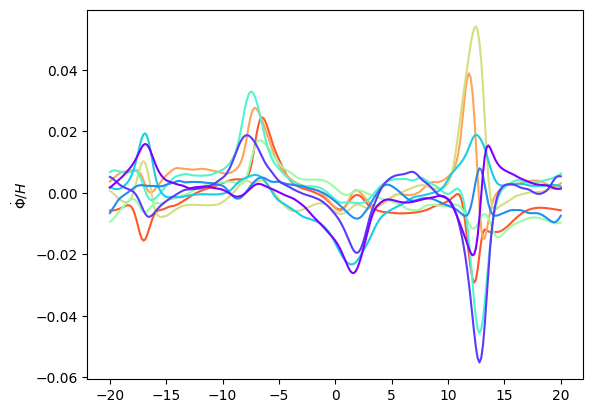

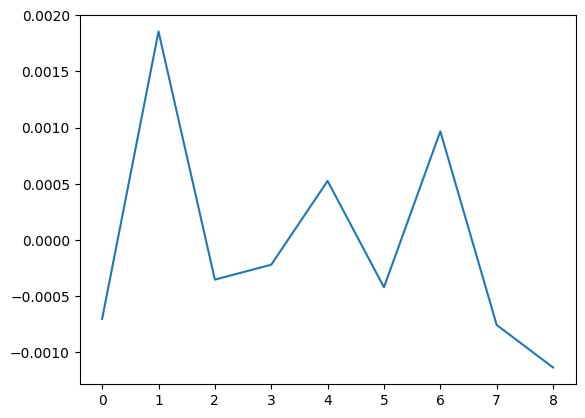

In [72]:
rel = []
for i in range_plot2:
    dt = times[i] - times[i-1] # Program units!
    dt /= B
    a = sf[i,1]
    constant = a * A ** 2
    print(dt)
    phi0 = np.loadtxt(f"Data/Phi/Phi{i-1}.txt") / constant
    phi = np.loadtxt(f"Data/Phi/Phi{i}.txt") / constant
    phidot = (phi - phi0) / dt
    H = (sf[i,2] + sf[i-1,2]) / (sf[i,1] + sf[i-1,1])
    H = (sf[i,2] + sf[i-1,2]) / 2
    phidot_rel = phidot / H
    plt.figure(2)
    plt.plot(np.linspace(-20,20,N),phidot_rel[N2,:],color=colours(i))
    rel.append(np.sum(phidot_rel / (np.size(phidot_rel))))
plt.figure(2)
plt.ylabel(r"$\dot{\Phi} / H$")
plt.savefig("Phi_dot vs H.png", dpi=200,facecolor='w',bbox_inches='tight')
#plt.ylim(bottom=1e-10)
#plt.savefig("Phi_dot_rel.png", dpi=200,facecolor='w',bbox_inches='tight')
plt.figure()
plt.plot(rel)

### $\langle \dot{\Phi} \rangle / \langle \Phi \rangle$

78072.76010972999
78073.5412669767
78072.7601097411
78072.76010972999
78072.7601097411
78072.7601097411
78072.76010972999
78072.7601097411
78073.5412669767


Text(0.5, 1.0, '$\\langle \\dot{\\Phi} \\rangle / \\langle \\Phi \\rangle$')

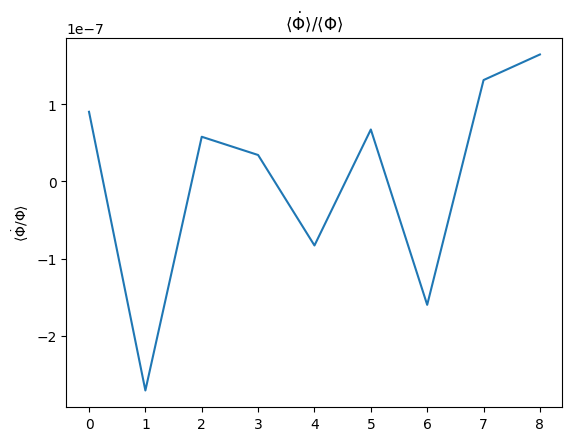

In [73]:
avg_rel = []
for i in range_plot2:
    dt = times[i] - times[i-1]
    dt /= B
    a = sf[i,1]
    constant = a * A ** 2
    print(dt)
    phi0 = np.loadtxt(f"Data/Phi/Phi{i-1}.txt") / constant
    phi = np.loadtxt(f"Data/Phi/Phi{i}.txt") / constant
    phidot = (phi - phi0) / dt
    phi_plot = (phi + phi0) / 2
    plot = np.sum(phidot) / np.sum(phi_plot) #/ N ** 2
    avg_rel.append(plot)

plt.plot(avg_rel)
plt.ylabel(r"$\langle \dot{\Phi} / \Phi \rangle$")
plt.title(r"$\langle \dot{\Phi} \rangle / \langle \Phi \rangle$")
#plt.ylim(bottom=1e-10)
#plt.savefig("Phi_dot_rel.png", dpi=200,facecolor='w',bbox_inches='tight')

### $\Phi / \phi$

Text(0.5, 1.0, '$\\langle \\Phi \\rangle / \\langle \\phi \\rangle$')

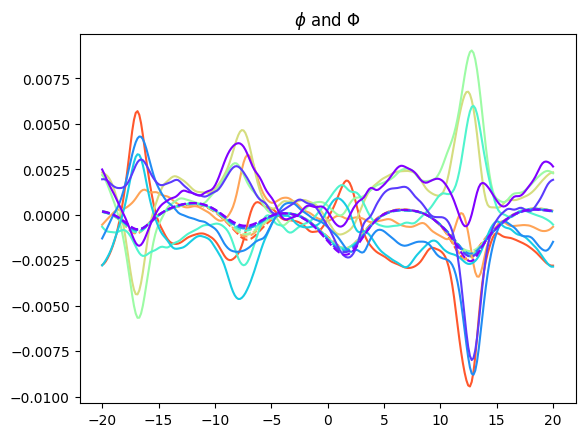

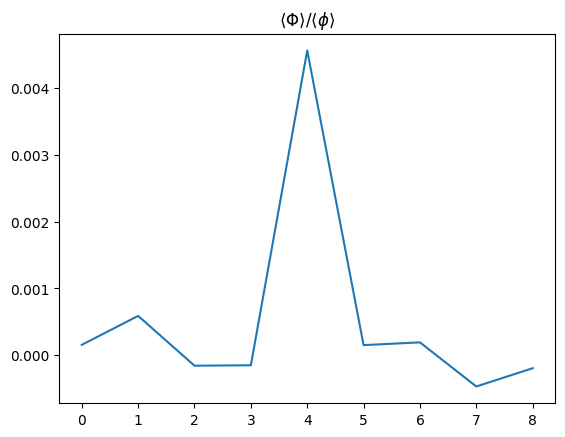

In [ ]:
rel = []
for i in range_plot2:
    size = N ** 3
    skip = i * (size + 1)
    a = sf[i,1]
    constant = a * A ** 2
    phi = np.loadtxt("../../../clustereasy/slices0_0.dat", skiprows=skip, max_rows=size)
    phi = np.reshape(phi, [N, N, N])    # Field
    phi /=  (A * a ** 1.5)
    data = np.loadtxt(f"Data/Phi/Phi{i}.txt") # Newtonian
    data /= constant
    plt.plot(np.linspace(-20, 20, N), phi[N2, :, N2],color=colours(i))
    plt.plot(np.linspace(-20, 20, N), data[N2,:],color=colours(i), linestyle='--')

    plot = np.sum(data) / np.sum(phi)
    rel.append(plot)
plt.title(r"$\phi$ and $\Phi$")
plt.savefig("phi vs Phi.png", dpi=200,facecolor='w',bbox_inches='tight')

plt.figure()
plt.plot(rel)
plt.title(r"$\langle \Phi \rangle / \langle \phi \rangle$")


Text(0.5, 1.0, '$\\phi$')

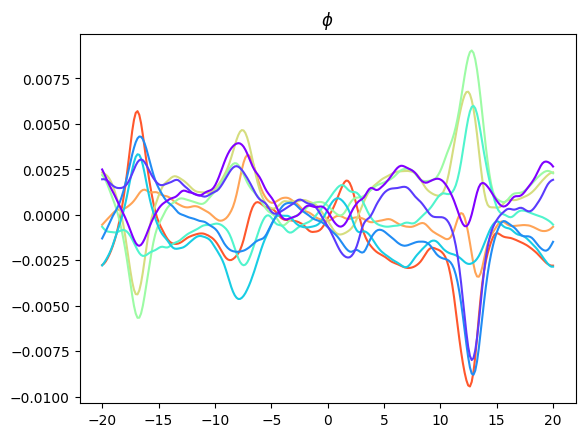

In [41]:

for i in range_plot2:
    size = N ** 3
    skip = i * (size + 1)
    a = sf[i,1]
    constant = a * A ** 2
    phi = np.loadtxt("../../../clustereasy/slices0_0.dat", skiprows=skip, max_rows=size)
    phi = np.reshape(phi, [N, N, N])    # Field
    phi /=  (A * a ** 1.5)
    data = np.loadtxt(f"Data/Phi/Phi{i}.txt") # Newtonian
    data /= constant
    plt.plot(np.linspace(-20, 20, N), phi[N2, :, N2],color=colours(i))


plt.title(r"$\phi$")

Text(0.5, 1.0, '$\\langle \\dot{\\Phi} \\rangle / \\langle \\dot{\\phi} \\rangle$')

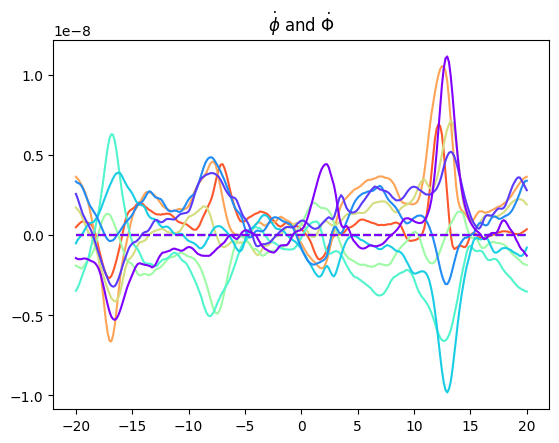

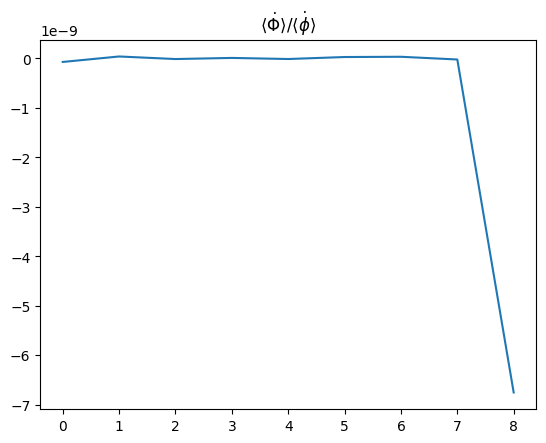

In [9]:
rel = []
for i in range_plot2:
    dt = times[i] - times[i-1]
    dt /= B
    size = N ** 3
    skip = i * (size + 1)
    a = sf[i,1]
    constant = a * A ** 2
    phi = np.loadtxt("../../../clustereasy/slicesp0_0.dat", skiprows=skip, max_rows=size)
    phi = np.reshape(phi, [N, N, N])    # Field
    phi /=  (A * a ** 1.5)
    phi *= B
    data = np.loadtxt(f"Data/Phi/Phi{i}.txt") # Newtonian
    data0 = np.loadtxt(f"Data/Phi/Phi{i-1}.txt")
    phidot = B * (data - data0) / dt
    phidot /= constant
    plt.plot(np.linspace(-20, 20, N), phi[N2, :, N2],color=colours(i))
    plt.plot(np.linspace(-20, 20, N), phidot[N2,:],color=colours(i), linestyle='--')

    plot = np.sum(phidot) / np.sum(phi)
    rel.append(plot)
plt.title(r"$\dot{\phi}$ and $\dot{\Phi}$")
plt.savefig("phi_dot vs Phi_dot.png", dpi=200,facecolor='w',bbox_inches='tight')
plt.figure()
plt.plot(rel)
plt.title(r"$\langle \dot{\Phi} \rangle / \langle \dot{\phi} \rangle$")

In [25]:
sf[28,1]

np.float64(2.783797)

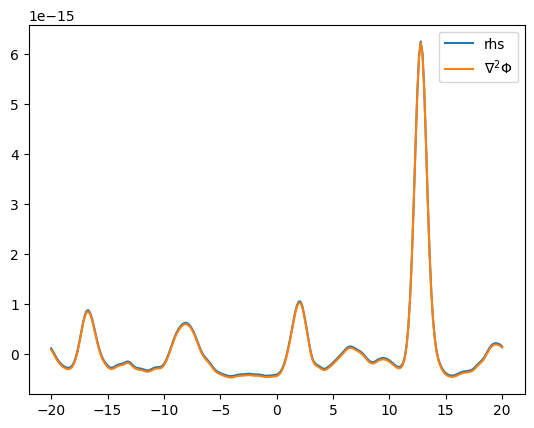

In [39]:
a = sf[28,1]
constant = a * A ** 2

rho = all_data_level_0["boxlib","rhs"][N2,:,N2] / 2.783797 * B ** 2 / A ** 2# / (4 * np.pi)
Phi = all_data_level_0["boxlib","Phi"] / constant

def plus(n):
    if n == N-1:
        return 0
    else:
        return n+1

def minus(n):
    if n == 0:
        return N-1
    else:
        return n-1

lapl = []
for i in range(N):
    lapl_add = (Phi[plus(N2),i,N2] + Phi[minus(N2), i, N2]
                + Phi[N2,plus(i),N2] + Phi[N2,minus(i), N2]
                + Phi[N2,i,plus(N2)] + Phi[N2,i,minus(N2)]
                - 6 * Phi[N2,i,N2]) * B ** 2 / (40 / 256) ** 2
    lapl.append(lapl_add)
r = np.linspace(-20,20,N)
plt.plot(r,rho,label="rhs")
plt.plot(r,lapl,label=r"$\nabla^2 \Phi$")
plt.legend()

In [33]:
print(np.max(rho))
print(np.max(lapl))

12.107853850474603 dimensionless
19.549501303925062


In [34]:
19.549501303925062/12.107853850474603

1.6146132539548916